In [1]:
using PhaseDiagram
import Plots
using Plots: plot, plot!
using LaTeXStrings
using ArgCheck
using CubicHermiteSpline
using Test

In [2]:
Plots.default(size=(600, 370))
fntf = :Helvetica
titlefont = Plots.font(fntf, pointsize=12)
guidefont = Plots.font(fntf, pointsize=12)
tickfont = Plots.font(fntf, pointsize=9)
legendfont = Plots.font(fntf, pointsize=8)
Plots.default(fontfamily=fntf)
Plots.default(titlefont=titlefont, guidefont=guidefont, tickfont=tickfont, legendfont=legendfont)
Plots.default(minorticks=true)
Plots.default(linewidth=1.2)
Plots.default(foreground_color_legend=nothing)
Plots.default(legend=false)

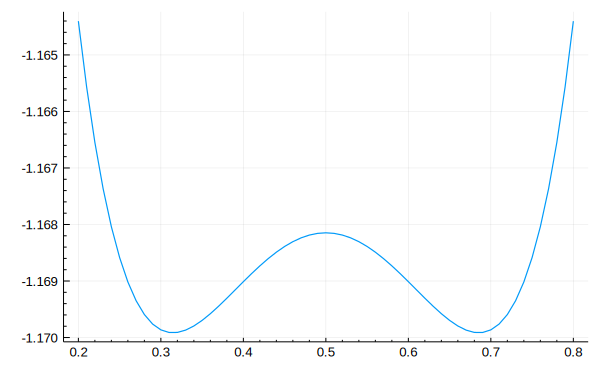

In [3]:
χN, f, α, C = 2.1, 0, 1, 1
ϕ = range(0.2, 0.8, step = 0.01)
plot(ϕ, [F(x, χN, f, α, C)[1] for x in ϕ])

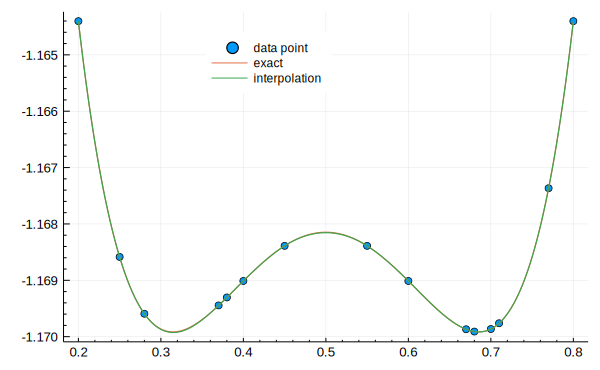

In [4]:
χN, f, α, C = 2.1, 0, 1, 1
ϕ = [0.2, 0.25, 0.28, 0.37, 0.38, 0.4, 0.45, 0.55, 0.6, 0.67, 0.68, 0.7, 0.71, 0.77, 0.8]
# ϕ = range(0.2, 0.8, step=0.05)
# ϕ = [0.2, 0.25]
y = [F(x, χN, f, α, C)[1] for x in ϕ]
gradient = [F(x, χN, f, α, C)[2] for x in ϕ]
xinterp = range(0.2, 0.8, step=0.001)
spl = CubicHermiteSplineInterpolation(ϕ, y, gradient)
yinterp = spl(xinterp)
Plots.scatter(ϕ, y, label="data point", legend=:top)
plot!(xinterp, [F(x, χN, f, α, C)[1] for x in xinterp], label="exact")
Plots.plot!(xinterp, yinterp, label="interpolation")

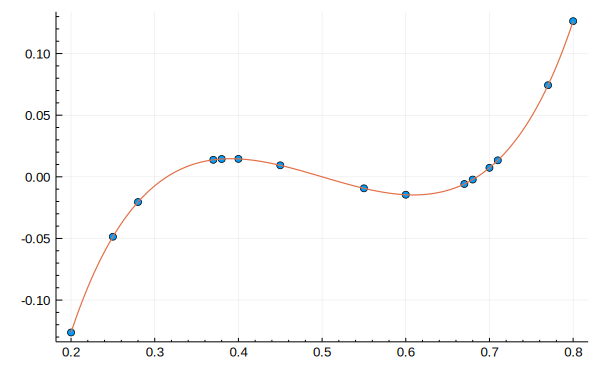

In [5]:
Plots.scatter(ϕ, gradient)
plot!(xinterp, [χN*(1-2x) + log(x/(1-x)) for x in xinterp])

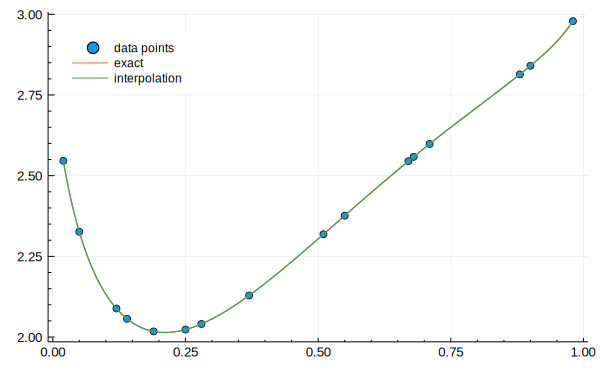

In [6]:
χN, f, α, C = 16, 0.4, 0.2, 1
ϕ = [0.02, 0.05, 0.12, 0.14,
     0.19, 0.25, 0.28, 0.37,
     0.51, 0.55, 0.67, 0.68,
     0.71, 0.88, 0.9, 0.98]
# ϕ = range(0.02, 0.98, step=0.05)
# ϕ = [0.2, 0.25]
y = [F(x, χN, f, α, C)[1] for x in ϕ]
gradient = [F(x, χN, f, α, C)[2]/α for x in ϕ]
xinterp = range(0.02, 0.98, step=0.001)
spl = CubicHermiteSplineInterpolation(ϕ, y, gradient)
yinterp = spl(xinterp)
Plots.scatter(ϕ, y, label="data points", legend=:topleft)
plot!(xinterp, [F(x, χN, f, α, C)[1] for x in xinterp], label="exact")
Plots.plot!(xinterp, yinterp, label="interpolation")